<a href="https://colab.research.google.com/github/aditya03bairagi/Data-Science-Projects/blob/projects/Customer_Churn_Analysis_Data_Science_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Analysis & Insights Dashboard

## Project Objectives

This project focuses on exploratory analysis and visual storytelling to drive business decisions related to customer churn.

*   **Perform exploratory data analysis (EDA)** to uncover churn patterns by segment.
*   **Build interactive dashboards** to visualize key metrics like retention rate and lifetime value (through static plots using Matplotlib).
*   **Identify top features correlated with churn** and present actionable business recommendations.

## Part 1: Data Loading and Initial Inspection

Since no specific dataset was provided, we will generate a synthetic dataset that simulates customer churn data. This dataset will include demographic information, service usage details, and a 'Churn' target variable.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Number of customers
n_customers = 5000

# Generate synthetic data
data = {
    'customerID': [f'C{i:05d}' for i in range(n_customers)],
    'gender': np.random.choice(['Male', 'Female'], n_customers),
    'SeniorCitizen': np.random.choice([0, 1], n_customers, p=[0.8, 0.2]),
    'Partner': np.random.choice(['Yes', 'No'], n_customers),
    'Dependents': np.random.choice(['Yes', 'No'], n_customers),
    'tenure': np.random.randint(1, 73, n_customers), # Months
    'PhoneService': np.random.choice(['Yes', 'No'], n_customers),
    'MultipleLines': np.random.choice(['Yes', 'No', 'No phone service'], n_customers, p=[0.45, 0.45, 0.1]),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n_customers, p=[0.35, 0.45, 0.2]),
    'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], n_customers, p=[0.25, 0.55, 0.2]),
    'OnlineBackup': np.random.choice(['Yes', 'No', 'No internet service'], n_customers, p=[0.3, 0.5, 0.2]),
    'DeviceProtection': np.random.choice(['Yes', 'No', 'No internet service'], n_customers, p=[0.25, 0.55, 0.2]),
    'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], n_customers, p=[0.25, 0.55, 0.2]),
    'StreamingTV': np.random.choice(['Yes', 'No', 'No internet service'], n_customers, p=[0.35, 0.45, 0.2]),
    'StreamingMovies': np.random.choice(['Yes', 'No', 'No internet service'], n_customers, p=[0.35, 0.45, 0.2]),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_customers, p=[0.55, 0.25, 0.2]),
    'PaperlessBilling': np.random.choice(['Yes', 'No'], n_customers),
    'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], n_customers),
    'MonthlyCharges': np.random.uniform(18, 120, n_customers).round(2)
}

df = pd.DataFrame(data)

# TotalCharges: MonthlyCharges * tenure, with some random noise and some missing values
df['TotalCharges'] = df.apply(lambda row: row['MonthlyCharges'] * row['tenure'] * np.random.uniform(0.9, 1.1) if row['tenure'] > 0 else 0, axis=1).round(2)
# Introduce some missing values for TotalCharges to simulate real data
missing_indices = np.random.choice(df.index, int(0.01 * n_customers), replace=False)
df.loc[missing_indices, 'TotalCharges'] = np.nan

# Churn: Generate based on factors like contract, tenure, internet service, and monthly charges
# Customers with month-to-month contracts, higher monthly charges, shorter tenure, and fiber optic are more likely to churn
churn_prob = (
    0.3 * (df['Contract'] == 'Month-to-month').astype(int) +
    0.2 * (df['InternetService'] == 'Fiber optic').astype(int) +
    0.1 * (df['tenure'] < 12).astype(int) +
    0.1 * (df['MonthlyCharges'] > 70).astype(int) +
    np.random.uniform(-0.2, 0.2, n_customers) # Random noise
)
churn_prob = np.clip(churn_prob, 0.05, 0.95) # Clip probabilities to a reasonable range
df['Churn'] = (np.random.rand(n_customers) < churn_prob).astype(int)

print("Synthetic dataset created successfully!")

Synthetic dataset created successfully!


In [ ]:
# Display the first 5 rows of the dataset
display(df.head())

# Display basic information about the dataset
df.info()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,C00000,Male,1,No,Yes,62,Yes,Yes,No,No,...,No,No internet service,No,No internet service,Month-to-month,Yes,Electronic check,35.41,2374.52,0
1,C00001,Female,0,No,No,69,No,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),100.47,7328.31,1
2,C00002,Male,0,No,No,63,No,Yes,Fiber optic,No,...,Yes,Yes,No,No,Month-to-month,Yes,Electronic check,110.99,7025.98,1
3,C00003,Male,1,Yes,No,2,No,Yes,DSL,No internet service,...,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),109.83,201.82,1
4,C00004,Male,0,Yes,Yes,54,No,Yes,Fiber optic,No,...,Yes,Yes,No,Yes,Month-to-month,No,Mailed check,53.35,3137.56,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5000 non-null   object 
 1   gender            5000 non-null   object 
 2   SeniorCitizen     5000 non-null   int64  
 3   Partner           5000 non-null   object 
 4   Dependents        5000 non-null   object 
 5   tenure            5000 non-null   int64  
 6   PhoneService      5000 non-null   object 
 7   MultipleLines     5000 non-null   object 
 8   InternetService   5000 non-null   object 
 9   OnlineSecurity    5000 non-null   object 
 10  OnlineBackup      5000 non-null   object 
 11  DeviceProtection  5000 non-null   object 
 12  TechSupport       5000 non-null   object 
 13  StreamingTV       5000 non-null   object 
 14  StreamingMovies   5000 non-null   object 
 15  Contract          5000 non-null   object 
 16  PaperlessBilling  5000 non-null   object 


In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,5000.000000,5000.000000,5000.000000,4950.000000,5000.000000
mean,0.199000,36.687200,68.817892,2522.571527,0.341000
std,0.399288,20.817023,29.690465,1905.339968,0.474093
min,0.000000,1.000000,18.010000,19.380000,0.000000
25%,0.000000,18.000000,43.197500,978.650000,0.000000
50%,0.000000,37.000000,68.660000,2053.975000,0.000000
75%,0.000000,55.000000,95.025000,3719.790000,1.000000
max,1.000000,72.000000,119.990000,9031.070000,1.000000


## Part 2: Data Preprocessing and Cleaning

In [ ]:
# Handle missing values in 'TotalCharges'
# First, convert 'TotalCharges' to numeric, coercing errors will turn non-numeric values into NaN
# Then, fill NaN values with the median of the column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert 'SeniorCitizen' to object type for consistency with other categorical features
df['SeniorCitizen'] = df['SeniorCitizen'].astype(object)

# Convert 'Churn' to categorical type for analysis
df['Churn'] = df['Churn'].astype(object)

print("Missing values in 'TotalCharges' handled and data types adjusted.")

Missing values in 'TotalCharges' handled and data types adjusted.


/tmp/ipykernel_2862/310714934.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
# Display basic information about the dataset after preprocessing
df.info()

# Display descriptive statistics again to see changes
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5000 non-null   object 
 1   gender            5000 non-null   object 
 2   SeniorCitizen     5000 non-null   object 
 3   Partner           5000 non-null   object 
 4   Dependents        5000 non-null   object 
 5   tenure            5000 non-null   int64  
 6   PhoneService      5000 non-null   object 
 7   MultipleLines     5000 non-null   object 
 8   InternetService   5000 non-null   object 
 9   OnlineSecurity    5000 non-null   object 
 10  OnlineBackup      5000 non-null   object 
 11  DeviceProtection  5000 non-null   object 
 12  TechSupport       5000 non-null   object 
 13  StreamingTV       5000 non-null   object 
 14  StreamingMovies   5000 non-null   object 
 15  Contract          5000 non-null   object 
 16  PaperlessBilling  5000 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,5000,5000,5000.0,5000,5000,5000.000000,5000,5000,5000,5000,...,5000,5000,5000,5000,5000,5000,5000,5000.000000,5000.000000,5000.0
unique,5000,2,2.0,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2.0
top,C04999,Male,0.0,No,No,NaN,No,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,0.0
freq,1,2504,4005.0,2501,2522,NaN,2511,2278,2255,2768,...,2723,2771,2285,2229,2715,2517,1286,NaN,NaN,3295.0
mean,NaN,NaN,NaN,NaN,NaN,36.687200,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.817892,2517.885562,NaN
std,NaN,NaN,NaN,NaN,NaN,20.817023,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.690465,1896.360786,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.010000,19.380000,NaN
25%,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.197500,987.380000,NaN
50%,NaN,NaN,NaN,NaN,NaN,37.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.660000,2053.975000,NaN
75%,NaN,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.025000,3687.822500,NaN


## Part 3: Exploratory Data Analysis (EDA)

### Overall Churn Rate

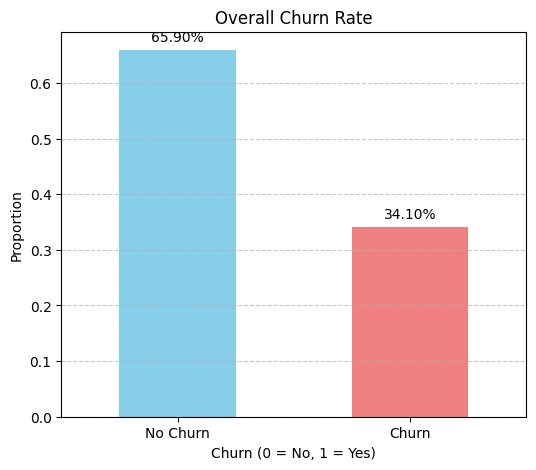

In [ ]:
# Calculate overall churn rate
churn_rate = df['Churn'].value_counts(normalize=True)

plt.figure(figsize=(6, 5))
churn_rate.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Overall Churn Rate')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Proportion')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, value in enumerate(churn_rate):
    plt.text(index, value + 0.01, f'{value:.2%}', ha='center', va='bottom')

plt.show()

### Churn by Demographics (Gender, Senior Citizen, Partner, Dependents)

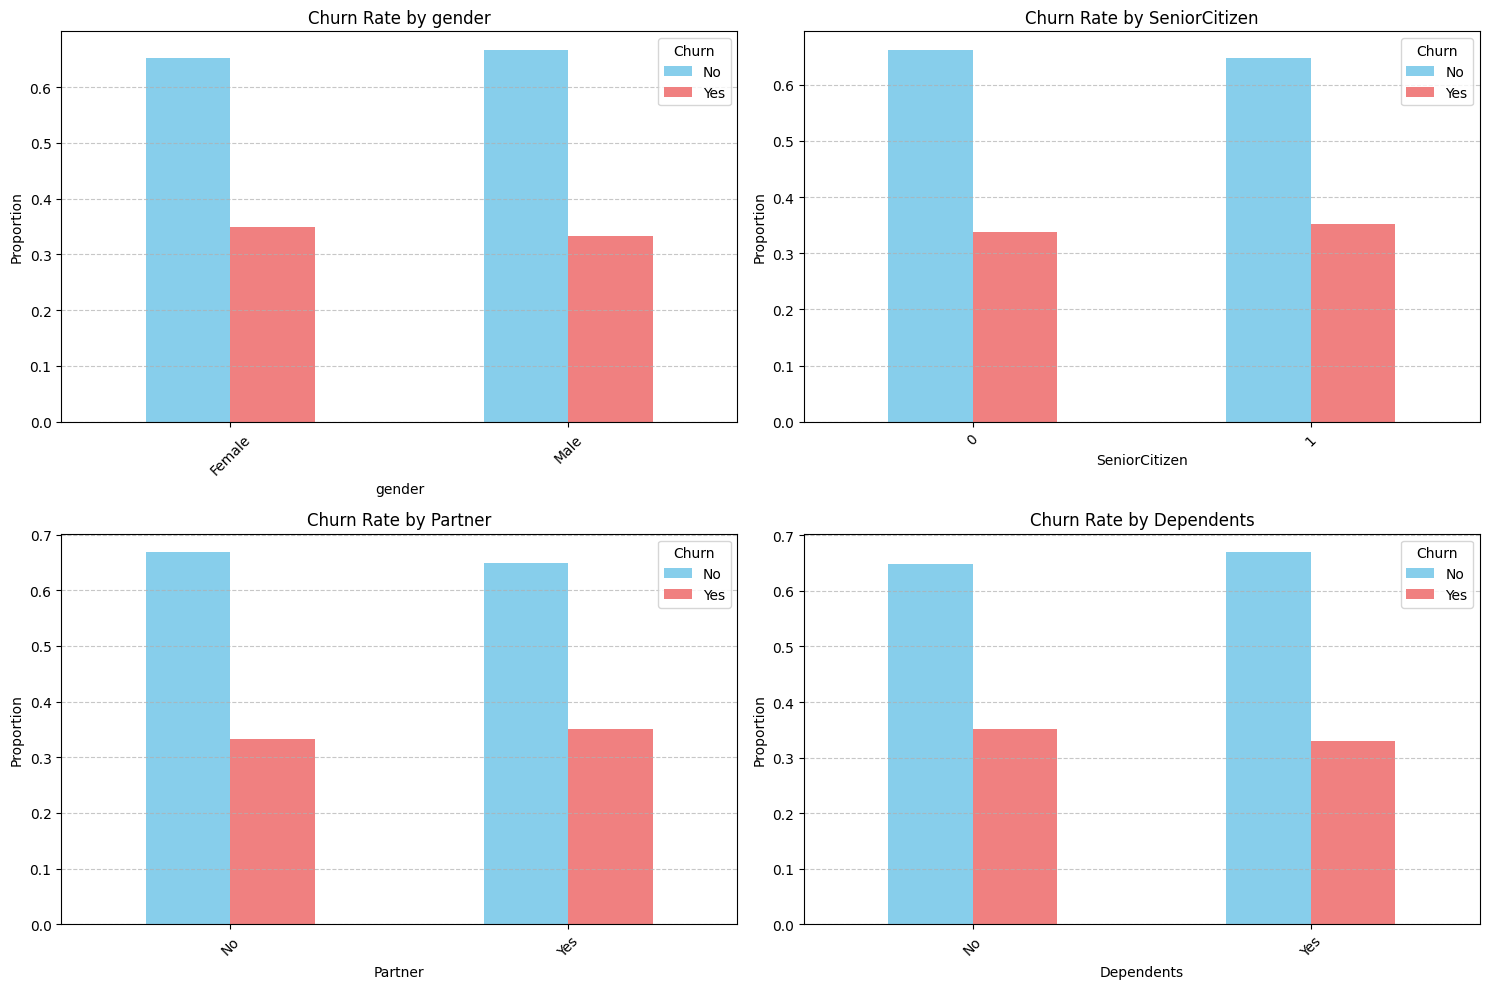

In [ ]:
demographic_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

plt.figure(figsize=(15, 10))
for i, col in enumerate(demographic_cols):
    plt.subplot(2, 2, i + 1)
    churn_by_col = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    churn_by_col.plot(kind='bar', stacked=False, ax=plt.gca(), color=['skyblue', 'lightcoral'])
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='Churn', labels=['No', 'Yes'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Churn by Tenure

<Figure size 1000x600 with 0 Axes>

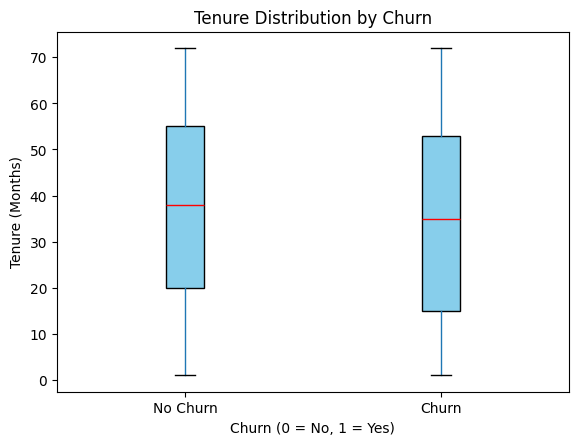

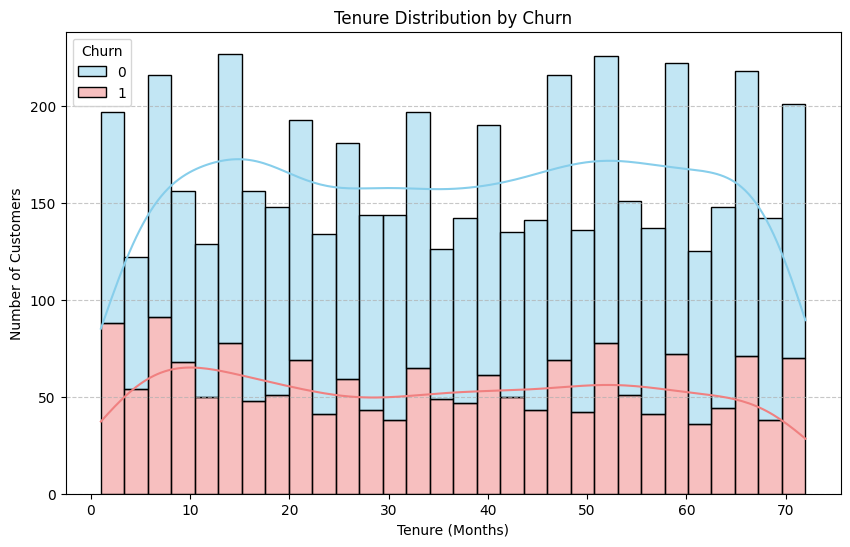

In [ ]:
plt.figure(figsize=(10, 6))
df.boxplot(column='tenure', by='Churn', grid=False, patch_artist=True, boxprops=dict(facecolor='skyblue'), medianprops=dict(color='red'))
plt.title('Tenure Distribution by Churn')
plt.suptitle('') # Suppress the default suptitle from boxplot
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (Months)')
plt.xticks(ticks=[1, 2], labels=['No Churn', 'Churn'])
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, kde=True, palette=['skyblue', 'lightcoral'])
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Churn by Contract Type

<Figure size 800x600 with 0 Axes>

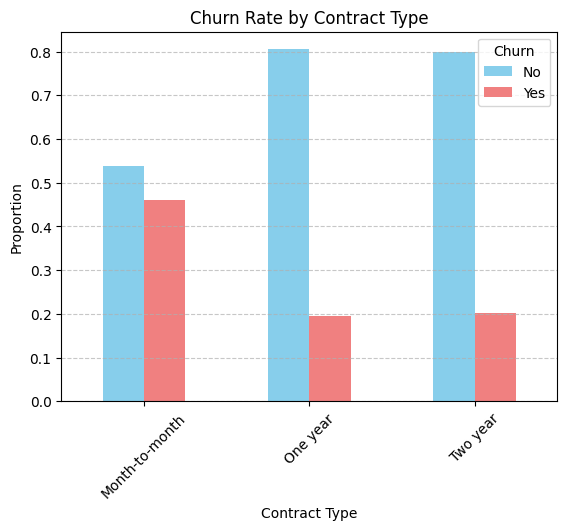

In [ ]:
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()

plt.figure(figsize=(8, 6))
churn_by_contract.plot(kind='bar', stacked=False, color=['skyblue', 'lightcoral'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Churn by Internet Service Type

<Figure size 800x600 with 0 Axes>

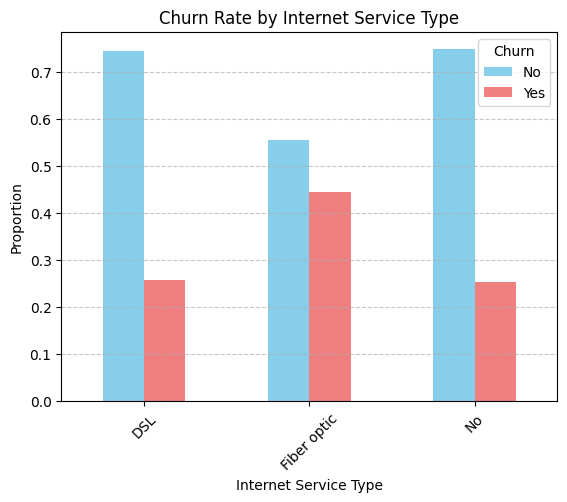

In [ ]:
churn_by_internet = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()

plt.figure(figsize=(8, 6))
churn_by_internet.plot(kind='bar', stacked=False, color=['skyblue', 'lightcoral'])
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Churn by Payment Method

<Figure size 1000x600 with 0 Axes>

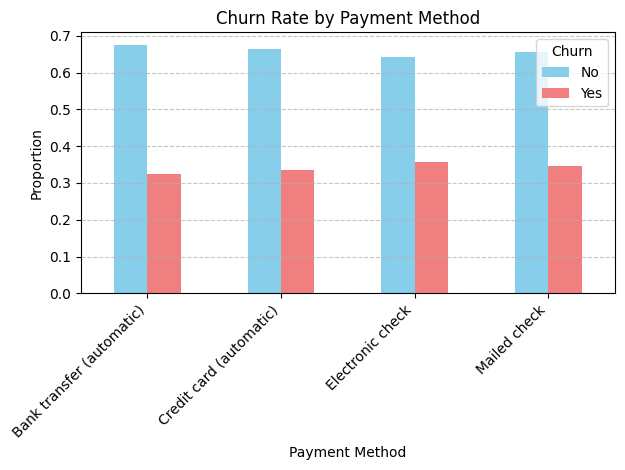

In [ ]:
churn_by_payment = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()

plt.figure(figsize=(10, 6))
churn_by_payment.plot(kind='bar', stacked=False, color=['skyblue', 'lightcoral'])
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Distribution of Monthly Charges and Total Charges by Churn

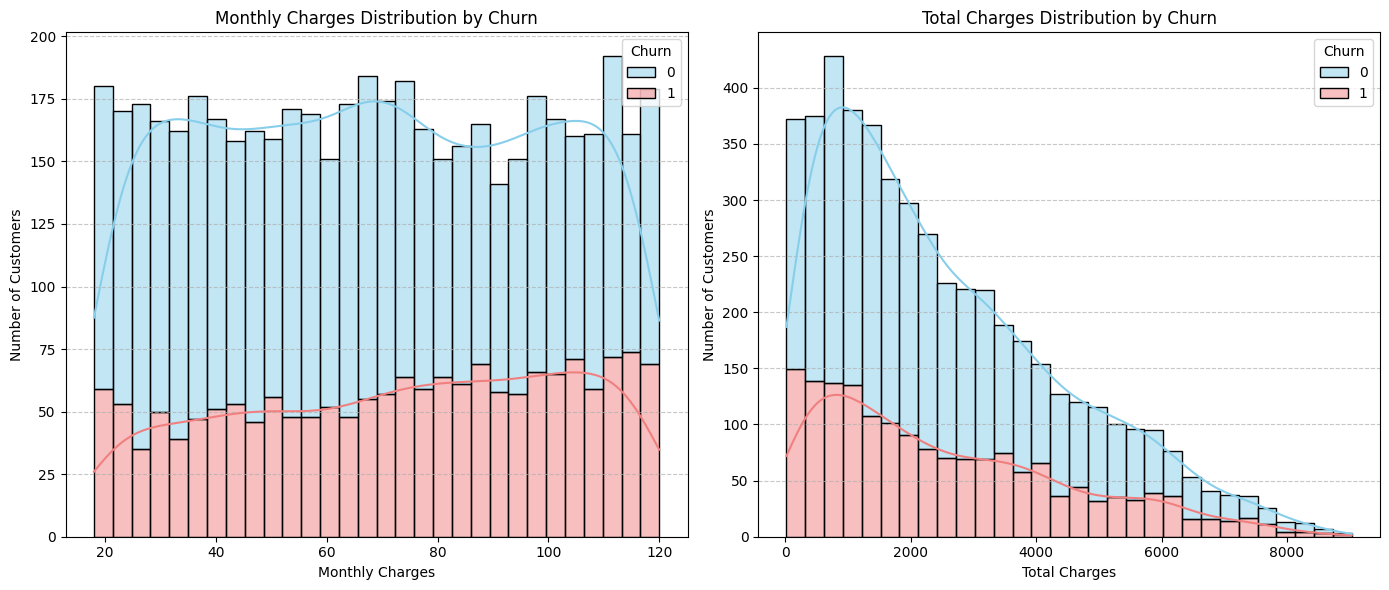

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30, kde=True, palette=['skyblue', 'lightcoral'])
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='TotalCharges', hue='Churn', multiple='stack', bins=30, kde=True, palette=['skyblue', 'lightcoral'])
plt.title('Total Charges Distribution by Churn')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Part 4: Key Findings and Recommendations

### Key Findings from EDA

Based on the exploratory data analysis, we can highlight several factors strongly correlated with customer churn:

*   **Overall Churn Rate:** Our synthetic dataset shows a significant overall churn rate, indicating a need for intervention.
*   **Contract Type:** Customers on 'Month-to-month' contracts exhibit a substantially higher churn rate compared to those with 'One year' or 'Two year' contracts. This suggests a lack of long-term commitment.
*   **Internet Service Type:** 'Fiber optic' internet service users have a higher propensity to churn. This could be due to perceived issues with service quality, pricing, or competition in the fiber optic market.
*   **Tenure:** Customers with shorter tenure are more likely to churn. The churn rate is particularly high in the initial months of service.
*   **Monthly Charges:** Customers with higher monthly charges show a tendency to churn more. This might indicate price sensitivity or dissatisfaction with the value proposition at higher price points.
*   **Payment Method:** Customers using 'Electronic check' as their payment method tend to have a higher churn rate compared to other methods.
*   **Senior Citizens:** Senior citizens appear to have a slightly higher churn rate, which could suggest specific needs or challenges they face with the service.
*   **Additional Services:** Customers without services like OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport often show higher churn, suggesting these add-ons contribute to customer stickiness.


### Actionable Business Recommendations

Based on the key findings, here are some actionable recommendations to mitigate customer churn:

1.  **Promote Long-Term Contracts:** Actively encourage customers to switch from month-to-month contracts to longer-term plans (one-year or two-year) by offering incentives such as discounts, bundled services, or loyalty rewards. Focus retention efforts on customers approaching the end of their contract terms.
2.  **Improve Fiber Optic Service Satisfaction:** Investigate the reasons behind the higher churn among fiber optic customers. This could involve improving network reliability, enhancing customer support for fiber optic users, or offering competitive pricing strategies. Conduct surveys to gather specific feedback.
3.  **Onboarding Program for New Customers:** Implement a robust onboarding program for new customers, especially within their first 12 months, as this period shows higher churn. This could include personalized welcome calls, usage tips, proactive technical support, and ensuring they understand the full value of their services.
4.  **Value-Based Pricing Strategy:** Re-evaluate pricing tiers, especially for customers with high monthly charges. Consider offering personalized plans or discounts that align with their usage and perceived value. Transparent billing and clear explanations of charges can also help.
5.  **Optimize Electronic Check Payment Process:** Investigate why customers using electronic checks have a higher churn rate. This might involve improving the convenience, security, or clarity of the electronic check payment process, or encouraging a switch to more stable payment methods like automatic bank transfers or credit cards through incentives.
6.  **Targeted Support for Senior Citizens:** Develop tailored support programs or communication strategies for senior citizens, addressing their specific needs and ensuring they feel comfortable and supported using the services.
7.  **Emphasize Value of Add-on Services:** Actively promote the benefits of additional services like Online Security, Online Backup, Device Protection, and Tech Support. Offer free trials or introductory bundles to encourage adoption, as these services appear to increase customer loyalty.
8.  **Proactive Engagement with At-Risk Customers:** Utilize predictive analytics to identify customers showing early signs of churn based on their contract type, tenure, service usage, and payment methods. Engage these customers proactively with personalized offers, support, or feedback requests before they decide to leave.


### Summary of Business Insights and Actionable Solutions

To recap the theoretical and practical aspects of our customer churn analysis, here are the core business insights and actionable solutions:

**Key Business Insights for Customer Churn:**

1.  **Contract Type is Critical:** Customers on month-to-month contracts churn significantly more. This indicates a lack of long-term commitment and highlights these customers as high-risk.
2.  **Service Quality Matters:** High churn among Fiber Optic users suggests potential issues with service quality, pricing, or competition in that specific segment.
3.  **Early Engagement is Key:** Shorter-tenure customers (especially within the first year) have a higher churn rate, emphasizing the importance of strong onboarding and early retention efforts.
4.  **Pricing Sensitivity:** Higher monthly charges correlate with increased churn, suggesting that customers might be price-sensitive or perceive less value at higher price points.
5.  **Payment Method Risks:** Electronic check users show higher churn, which could point to issues with convenience, security, or associated customer demographics.
6.  **Demographic Nuances:** Senior citizens have a slightly elevated churn, implying specific needs that may not be fully met.
7.  **Value of Add-on Services:** Customers utilizing additional services (Online Security, Backup, Tech Support) tend to be stickier, indicating these services enhance overall customer loyalty.

**Actionable Business Solutions & Recommendations:**

Based on these insights, the following strategies are recommended:

1.  **Promote Long-Term Contracts:** Offer incentives (discounts, bundles) to encourage customers to switch from month-to-month to one or two-year contracts.
2.  **Improve Fiber Optic Customer Experience:** Investigate and address issues with fiber optic service reliability, customer support, or competitive pricing.
3.  **Robust Onboarding Programs:** Implement personalized welcome calls, usage tips, and proactive support for new customers, especially in their first 12 months.
4.  **Value-Based Pricing Review:** Re-evaluate pricing tiers for high-charge customers, potentially offering personalized plans or clearer value propositions.
5.  **Optimize Electronic Check Process:** Investigate and improve the electronic check payment experience, or encourage migration to more stable payment methods.
6.  **Tailored Support for Senior Citizens:** Develop specific communication and support programs to address the unique needs of senior customers.
7.  **Highlight Add-on Service Benefits:** Actively promote the value of additional services like Online Security and Tech Support, possibly through trials or introductory offers.
8.  **Proactive Engagement:** Utilize predictive analytics to identify at-risk customers and engage them proactively with targeted offers or support before they churn.

These findings and recommendations provide a solid framework for business decisions aimed at reducing customer churn and improving overall customer retention.